In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

input_path = "../data/raw/dataset.csv"


In [5]:
df = pd.read_csv(input_path)
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [9]:
df = df.drop(columns=["Unnamed: 0", "track_id"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           113999 non-null  object 
 1   album_name        113999 non-null  object 
 2   track_name        113999 non-null  object 
 3   popularity        114000 non-null  int64  
 4   duration_ms       114000 non-null  int64  
 5   explicit          114000 non-null  bool   
 6   danceability      114000 non-null  float64
 7   energy            114000 non-null  float64
 8   key               114000 non-null  int64  
 9   loudness          114000 non-null  float64
 10  mode              114000 non-null  int64  
 11  speechiness       114000 non-null  float64
 12  acousticness      114000 non-null  float64
 13  instrumentalness  114000 non-null  float64
 14  liveness          114000 non-null  float64
 15  valence           114000 non-null  float64
 16  tempo             11

In [16]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
print("Numeric column names:", numeric_columns)

Numeric column names: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


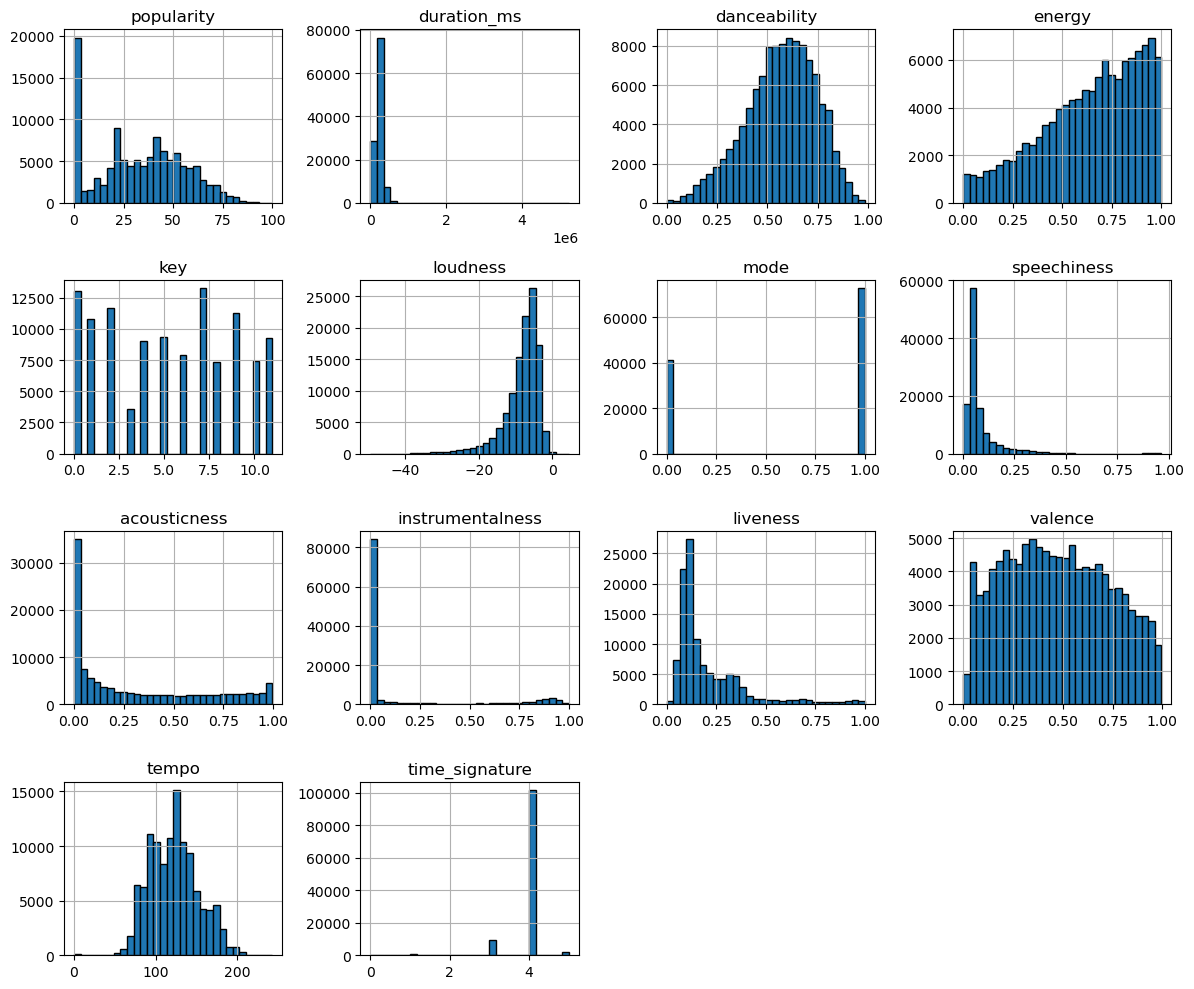

In [18]:
df.hist(bins=30, figsize=(12, 10), edgecolor="black")
plt.tight_layout()  # Prevents labels from overlapping
plt.show()

In [17]:
df.drop(columns=numeric_columns).describe().T

,count,unique,top,freq
artists,113999,31437,The Beatles,279
album_name,113999,46589,Alternative Christmas 2022,195
track_name,113999,73608,Run Rudolph Run,151
explicit,114000,2,False,104253
track_genre,114000,114,acoustic,1000


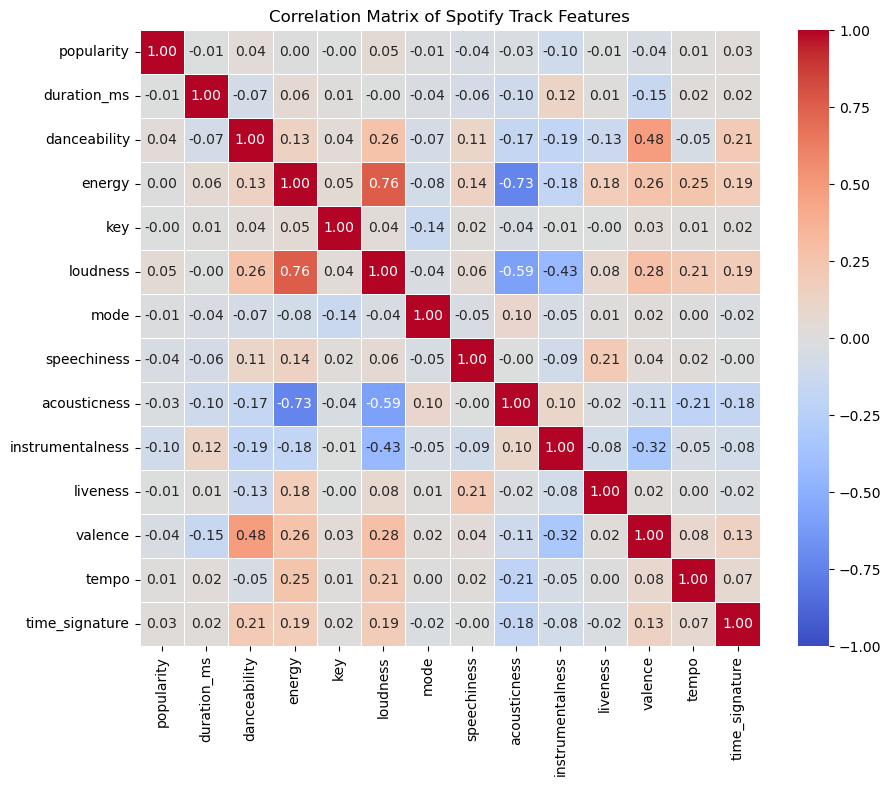

In [20]:
corr_matrix = df.select_dtypes(include="number").corr()

# 2. Set up the figure size
plt.figure(figsize=(10, 8))

# 3. Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,  # Show the actual correlation numbers in the cells
    cmap="coolwarm",  # Color scheme (blue = negative, red = positive)
    fmt=".2f",  # Format numbers to 2 decimal places
    linewidths=0.5,  # Add white grid lines between boxes
    vmin=-1,
    vmax=1,  # Anchor the color scale from -1 to 1
)

plt.title("Correlation Matrix of Spotify Track Features")
plt.show()